# Set up workspace

In [1]:
import geopandas as gpd

# Define parameters

In [2]:
from srm import run_bcsd

# Run through clunky BCSD workflow

In [6]:
RUN_PARAMETERS = {
    "OBS": "ERA5",
    "GCM": "CESM2-WACCM",
    "TRAIN_PERIOD_START": 1978,
    "TRAIN_PERIOD_END": 2014,
    "PREDICT_PERIOD_START": 2015,
    "PREDICT_PERIOD_END": 2100,
    "VAR": "tas",
}

In [3]:
# Rechunking in between steps
dict_all = run_bcsd.main(run_parameters=RUN_PARAMETERS)

Loaded data: 1.41 seconds
Subset time: 0.19 seconds
Rechunked obs to full space: 53.96 seconds
Interpolated obs to coarse grid: 0.08 seconds
Rechunked all to full time: 18.39 seconds


100%|██████████| 55296/55296 [01:11<00:00, 772.71it/s]


Quantile mapped historical: 80.28 seconds


100%|██████████| 55296/55296 [02:11<00:00, 419.24it/s]


Quantile mapped future: 144.63 seconds
Calculate error map for spatial disaggregation: 149.54 seconds
Downscaled historical: 247.98 seconds
Downscaled future: 854.91 seconds
TOTAL TIME: 1549.98 seconds


In [ ]:
# Not rechunking in between steps
# dict_all = run_bcsd.main(rechunk_workflow=False)

# Save results

In [5]:
%%time
for key in ["model_hist_debiased_downscaled", "ssp245_debiased_downscaled"]:
    s3_path = "s3://carbonplan-scratch/srm-scratch/v0.2_global/" + key + ".zarr"
    ds = dict_all[key].to_dataset(name=RUN_PARAMETERS["VAR"])
    ds.to_zarr(s3_path, encoding={var: {"shards": None} for var in ds.data_vars}, mode="w")

/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


CPU times: user 24min 35s, sys: 3min 7s, total: 27min 42s
Wall time: 11min 44s


# Look at results

In [4]:
%%time
dict_all["model_hist_debiased_downscaled"] = dict_all["model_hist_debiased_downscaled"].chunk(
    time=1000, lat=7, lon=7
)

CPU times: user 3.72 s, sys: 89.3 ms, total: 3.81 s
Wall time: 3.81 s


In [5]:
%%time
dict_all["ssp245_debiased_downscaled"] = dict_all["ssp245_debiased_downscaled"].chunk(
    time=1000, lat=7, lon=7
)

CPU times: user 7.53 s, sys: 176 ms, total: 7.71 s
Wall time: 7.71 s


In [6]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_6455/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_6455/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


CPU times: user 4min 31s, sys: 1min 5s, total: 5min 37s
Wall time: 1min 1s


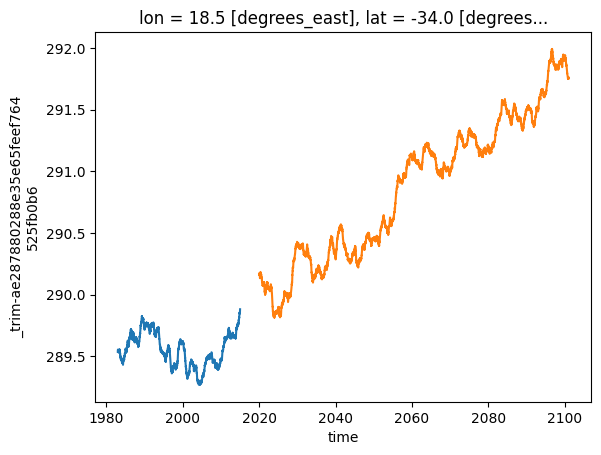

In [7]:
%%time
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot()
dict_all["ssp245_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot()

# Save output

In [8]:
ds = dict_all["ssp245_debiased_downscaled"]
s3_path = "s3://carbonplan-scratch/srm-scratch/v0.2_global/ssp245_debiased_downscaled.zarr"
ds.to_zarr(s3_path)

/opt/coiled/env/lib/python3.13/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


TypeError: Session.__init__() got an unexpected keyword argument 'asynchronous'